In [ ]:
#import library
import pandas as pd

#Read dataset
retail_df = pd.read_csv('https://confrecordings.ams3.digitaloceanspaces.com/Retail_1.csv')

#Perform EDA
print(retail_df.head())
print(retail_df.isnull().sum())
retail_df = retail_df.dropna()
#retail_df = retail_df.columns[retail_df.columns.str.contains('C')]
print(retail_df.shape)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
InvoiceNo         0
StockCode         0
Description      42
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     2290
Country           0
dtype: int64
(5709, 8)


In [ ]:
# new column: Monetary
retail_df['Monetary'] = retail_df['Quantity']*retail_df['UnitPrice']
grouped_df = retail_df.groupby('CustomerID')['Monetary'].sum()
grouped_df = grouped_df.reset_index()
print(grouped_df.head(2))


# new column :frequency
frequency = retail_df.groupby('CustomerID')['InvoiceNo'].count()
frequency = frequency.reset_index()
frequency.columns = ['CustomerID','InvoiceNo']
print(frequency.head(2))

# new column :recency
# convert to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'], format='%d-%m-%Y %H:%M')
# compute the diff
retail_df['diff'] = max(retail_df['InvoiceDate']) - retail_df['InvoiceDate']

# new column: recency
last_purchase = retail_df.groupby('CustomerID')['diff'].min()
last_purchase = last_purchase.reset_index()
print(last_purchase.head(2))

# merge the two dfs
grouped_df = pd.merge(grouped_df, frequency, on='CustomerID', how='inner')
print(grouped_df.head())

# merge the third dataframe
rfm = pd.merge(grouped_df, last_purchase, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Monetary', 'frequency', 'recency']
# number of days only
rfm['recency'] = rfm['recency'].dt.days
print(rfm.head(2))



   CustomerID  Monetary
0     12395.0     346.1
1     12427.0     303.5
   CustomerID  InvoiceNo
0     12395.0         12
1     12427.0         10
   CustomerID            diff
0     12395.0 1 days 19:25:00
1     12427.0 2 days 01:16:00
   CustomerID  Monetary  InvoiceNo
0     12395.0    346.10         12
1     12427.0    303.50         10
2     12431.0    358.25         14
3     12433.0   1919.14         73
4     12471.0    -17.00          1
   CustomerID  Monetary  frequency  recency
0     12395.0     346.1         12        1
1     12427.0     303.5         10        2


In [ ]:
frequency = retail_df.groupby('CustomerID')['InvoiceNo'].sum()
frequency = frequency.reset_index()
frequency.columns = ['CustomerID','InvoiceNo']
print(frequency.head())

   CustomerID                                          InvoiceNo
0     12395.0  5370265370265370265370265370265370265370265370...
1     12427.0  5368615368615368615368615368615368615368615368...
2     12431.0  5363895363895363895363895363895363895363895363...
3     12433.0  5365325365325365325365325365325365325365325365...
4     12471.0                                            C536622


   Monetary  frequency   recency  cluster_id
0 -0.112712  -0.327062 -1.162762           0
1 -0.161803  -0.403033 -0.215453           0
2 -0.098711  -0.251090  1.679165           2
3  1.700005   1.990071  0.731856           2
4 -0.531136  -0.744905  0.731856           2


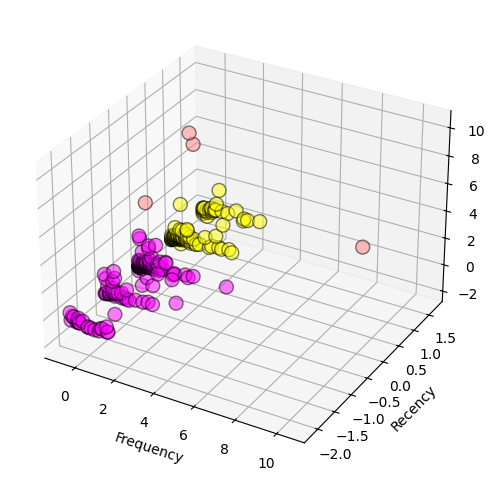

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# instantiate
scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm[['Monetary','frequency','recency']])
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['Monetary', 'frequency', 'recency']
rfm_df_scaled.head()

#Train the KMeans with n_clsuters =3
kmeans = KMeans(n_clusters=3, max_iter=50)
kmeans.fit(rfm_df_scaled)
rfm_df_scaled['cluster_id'] = kmeans.labels_
print(rfm_df_scaled.head())

#Plot the clustered graph
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rfm_df_scaled['frequency'], rfm_df_scaled['recency'], rfm_df_scaled['Monetary'],
           linewidths=1, alpha=.5,
           edgecolor='black',
           s = 100,
           cmap='spring',
           c=rfm_df_scaled['cluster_id'])
ax.set_xlabel("Frequency")
ax.set_ylabel("Recency")
ax.set_zlabel("Amount")
plt.show()


In [ ]:
rfm[['Monetary','frequency','recency']]

,Monetary,frequency,recency
0,346.10,12,1
1,303.50,10,2
2,358.25,14,4
3,1919.14,73,3
4,-17.00,1,3
...,...,...,...
272,165.05,3,3
273,246.35,31,2
274,-31.80,1,2
275,344.20,7,3
